# Poison dart frogs

Can you estimate how toxic a poison dart frog is based on its brightness?

Poison dart frogs are small, colorful frogs from Central and South America. They're famous for their toxic skin, which some indigenous people use for blow darts.

Scientists studied the connection between the bright colors and toxicity of the poison dart frog **Dendrobates pumilio**. While they're usually red with blue legs, they can be found in about 15 different colors in Panama.

The file `frog-reflectance.csv` contains the average brightness (from 0 to 1) of 10 frog populations, measured on both the back and belly.

The file `frog-toxicity.csv` provides a `toxicity` score (from 0 to 1) for 48 frogs from the same 10 populations. Toxicity was tested by injecting frog skin extracts into mice and recording how long it took them to fall back asleep. Longer times suggest higher `toxicity`.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'frog-reflectance.csv', 'frog-toxicity.csv', and 'linear_model.py'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('frog-reflectance.csv')
df.head()

,pop_id,back_brightness,belly_brightness
0,AG,0.43,0.46
1,AL,0.64,0.42
2,BCG,1.00,0.95
3,BCO,0.82,1.00
4,CA,0.46,0.51


In [3]:
tox = pd.read_csv('frog-toxicity.csv')
tox.head()

,pop_id,frog_id,toxicity
0,BCO,BC167,0.886925
1,BCO,BC166,0.803917
2,BCO,BC171,0.625008
3,BCO,BC169,0.975847
4,BCO,BC165,0.774033


# Project Ideas

- Build two linear models:
	- Model 1: `toxicity` (x-axis) vs. `back_brightness`
	
	- Model 2: `toxicity` vs. `belly_brightness`

- To create the models, first calculate the average `toxicity` for each `pop_id`, then merge these values into the main dataframe (`df`).

- Visualize the data by creating scatter plots with best-fit lines for both models.

- Compare the goodness of fit between back and belly brightness and explore possible biological explanations for any differences in correlation.


In [4]:
# YOUR CODE HERE (add additional cells as needed)

# Linear model API

# linear = LinearModel()
# linear.fit(x, y)
# linear.predict(x)
# linear.plot_model(x_min, x_max, color="black")
# linear.print_model_info(self):


In [7]:
# ── 1. Average toxicity per population, then merge into df ────────────────────
avg_tox = tox.groupby('pop_id')['toxicity'].mean().reset_index()
avg_tox.columns = ['pop_id', 'avg_toxicity']

df = df.merge(avg_tox, on='pop_id')
df

,pop_id,back_brightness,belly_brightness,avg_toxicity
0,AG,0.43,0.46,0.632902
1,AL,0.64,0.42,0.500877
2,BCG,1.00,0.95,0.885207
3,BCO,0.82,1.00,0.813146
4,CA,0.46,0.51,0.364581
5,CO,0.61,0.62,0.209414
6,PoSo,0.49,0.58,0.293478
7,SC,0.67,0.53,0.618246
8,SH,0.46,0.36,0.387053
9,SO,0.87,0.49,1.000000


In [8]:
# ── 2. Fit Model 1: avg_toxicity (x) vs back_brightness (y) ──────────────────
model_back = LinearModel()
model_back.fit(df['avg_toxicity'], df['back_brightness'])
print("Model 1 — Toxicity vs Back Brightness:")
model_back.print_model_info()

Model 1 — Toxicity vs Back Brightness:
LinearModel():
Slope: 0.5758129980180036
Intercept: 0.3165043254009716
R-squared: 0.6067780219154056


In [9]:
# ── 3. Fit Model 2: avg_toxicity (x) vs belly_brightness (y) ─────────────────
model_belly = LinearModel()
model_belly.fit(df['avg_toxicity'], df['belly_brightness'])
print("Model 2 — Toxicity vs Belly Brightness:")
model_belly.print_model_info()

Model 2 — Toxicity vs Belly Brightness:
LinearModel():
Slope: 0.34762229493312424
Intercept: 0.3936848861127157
R-squared: 0.18431612963411392


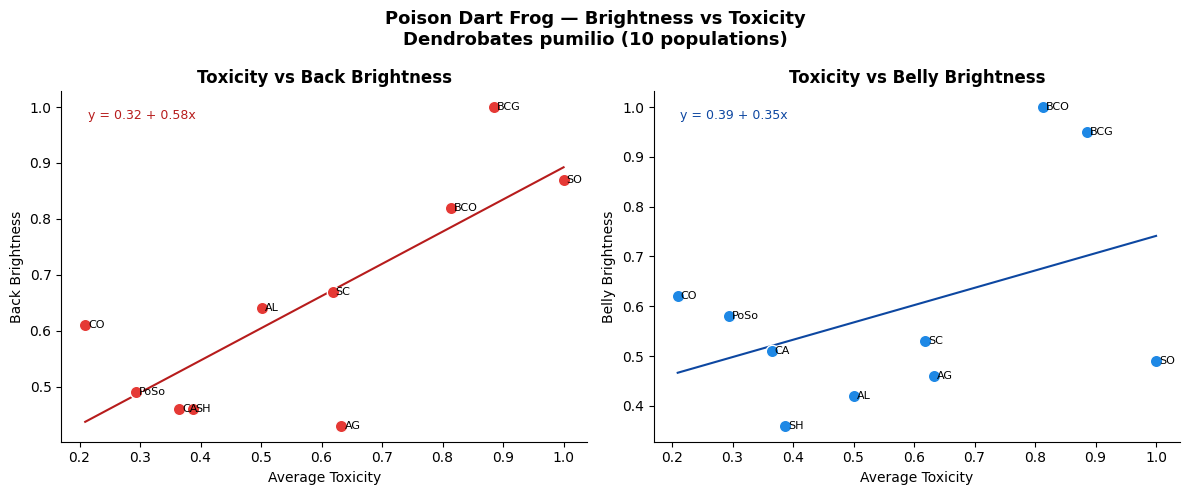

In [10]:
# ── 4. Side-by-side scatter plots with best-fit lines ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# ---- Plot 1: Back brightness ----
ax = axes[0]
ax.scatter(df['avg_toxicity'], df['back_brightness'],
           color='#E53935', edgecolors='white', s=80, zorder=3)

# Label each population point
for _, row in df.iterrows():
    ax.text(row['avg_toxicity'] + 0.005, row['back_brightness'],
            row['pop_id'], fontsize=8, va='center')

# Best-fit line using plot_model (draws onto current active axes)
plt.sca(ax)
model_back.plot_model(df['avg_toxicity'].min(), df['avg_toxicity'].max(),
                      color='#B71C1C')

ax.set_xlabel('Average Toxicity')
ax.set_ylabel('Back Brightness')
ax.set_title('Toxicity vs Back Brightness', fontweight='bold')
eq_back = f"y = {model_back.intercept:.2f} + {model_back.slope:.2f}x"
ax.text(0.05, 0.95, eq_back, transform=ax.transAxes,
        fontsize=9, va='top', color='#B71C1C')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---- Plot 2: Belly brightness ----
ax = axes[1]
ax.scatter(df['avg_toxicity'], df['belly_brightness'],
           color='#1E88E5', edgecolors='white', s=80, zorder=3)

for _, row in df.iterrows():
    ax.text(row['avg_toxicity'] + 0.005, row['belly_brightness'],
            row['pop_id'], fontsize=8, va='center')

plt.sca(ax)
model_belly.plot_model(df['avg_toxicity'].min(), df['avg_toxicity'].max(),
                       color='#0D47A1')

ax.set_xlabel('Average Toxicity')
ax.set_ylabel('Belly Brightness')
ax.set_title('Toxicity vs Belly Brightness', fontweight='bold')
eq_belly = f"y = {model_belly.intercept:.2f} + {model_belly.slope:.2f}x"
ax.text(0.05, 0.95, eq_belly, transform=ax.transAxes,
        fontsize=9, va='top', color='#0D47A1')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Poison Dart Frog — Brightness vs Toxicity\nDendrobates pumilio (10 populations)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# ── 5. Summary comparison table ───────────────────────────────────────────────
print("Model Comparison")
print("=" * 50)
print(f"{'Metric':<30} {'Back':>9} {'Belly':>9}")
print("-" * 50)
print(f"{'Slope':<30} {model_back.slope:>9.3f} {model_belly.slope:>9.3f}")
print(f"{'Intercept':<30} {model_back.intercept:>9.3f} {model_belly.intercept:>9.3f}")
print()

Model Comparison
Metric                              Back     Belly
--------------------------------------------------
Slope                              0.576     0.348
Intercept                          0.317     0.394

